# 13장 영상 분류 사전 학습 모델 활용하기 1

* "부록3 매트플롯립 입문"에서 한글 폰트를 올바르게 출력하기 위한 설치 방법을 설명했다. 설치 방법은 다음과 같다.

In [ ]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 76, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.12.6-0ubuntu2) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 31 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such 

In [ ]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

* 모든 설치가 끝나면 한글 폰트를 바르게 출력하기 위해 **[런타임]** -> **[런타임 다시시작]**을 클릭한 다음, 아래 셀부터 코드를 실행해 주십시오.

In [2]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 폰트 관련 용도
import matplotlib.font_manager as fm

# Colab, Linux
# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

# Window 
# font_name = "NanumBarunGothic"

# Mac
# font_name = "AppleGothic"

In [1]:
# 파이토치 관련 라이브러리

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchviz import make_dot
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

c:\Users\user\anaconda3\envs\torchgpu_py3.9\lib\site-packages\google\protobuf\runtime_version.py:112: UserWarning: Protobuf gencode version 5.27.5 is older than the runtime version 5.28.2 at onnx/onnx-ml.proto. Please avoid checked-in Protobuf gencode that can be obsolete.
  warnings.warn(
c:\Users\user\anaconda3\envs\torchgpu_py3.9\lib\site-packages\google\protobuf\runtime_version.py:112: UserWarning: Protobuf gencode version 5.27.5 is older than the runtime version 5.28.2 at onnx/onnx-operators-ml.proto. Please avoid checked-in Protobuf gencode that can be obsolete.
  warnings.warn(
c:\Users\user\anaconda3\envs\torchgpu_py3.9\lib\site-packages\google\protobuf\runtime_version.py:112: UserWarning: Protobuf gencode version 5.27.5 is older than the runtime version 5.28.2 at onnx/onnx-data.proto. Please avoid checked-in Protobuf gencode that can be obsolete.
  warnings.warn(


In [4]:
# warning 표시 끄기
import warnings
warnings.simplefilter('ignore')

# 기본 폰트 설정
plt.rcParams['font.family'] = font_name  # window font

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [5]:
# GPU 디바이스 할당

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


### 공통 함수 불러오기

In [6]:
# 공통 함수 다운로드
!git clone https://github.com/wikibook/pythonlibs.git

# 공통 함수 불러오기
from pythonlibs.torch_lib1 import *
# from torch_lib1 import *


# 공통 함수 확인
print(README)

Common Library for PyTorch
Author: M. Akaishi


## 적응형 풀링 함수(nn.AdaptiveAvgPool2d 함수)

In [8]:
# nn.AdaptiveAvgPool2d 정의
p = nn.AdaptiveAvgPool2d((1,1))
print(p)

# 선형 함수의 정의
l1 = nn.Linear(32, 10)
print(l1)

AdaptiveAvgPool2d(output_size=(1, 1))
Linear(in_features=32, out_features=10, bias=True)


In [13]:
m = nn.AdaptiveAvgPool2d((5, 7))
input = torch.randn(1, 64, 8, 9)
print(m(input).shape)

input2 = torch.randn(1, 64, 32, 30)
print(m(input2).shape)

torch.Size([1, 64, 5, 7])
torch.Size([1, 64, 5, 7])


In [14]:
# 사전 학습 모델 시뮬레이션
inputs = torch.randn(100, 32, 16, 16)
m1 = p(inputs)
m2 = m1.view(m1.shape[0],-1)
m3 = l1(m2)

# shape 확인
print(m1.shape)
print(m2.shape)
print(m3.shape)

torch.Size([100, 32, 1, 1])
torch.Size([100, 32])
torch.Size([100, 10])


## 데이터 준비

In [16]:
# 분류 클래스명 정의

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 분류 클래스 수는 10
n_output = len(classes)

In [18]:
# Transforms 정의

# 학습 데이터용 : 정규화에 반전과 RandomErasing 추가
transform_train = transforms.Compose([
  transforms.Resize(112),
  transforms.RandomHorizontalFlip(p=0.5), 
  transforms.ToTensor(),
  transforms.Normalize(0.5, 0.5), 
  transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False)
])

# 검증 데이터용 : 정규화만 실시
transform = transforms.Compose([
  transforms.Resize(112),
  transforms.ToTensor(),
  transforms.Normalize(0.5, 0.5)
])

In [19]:
# 데이터 취득용 함수 dataset

data_root = './data'

train_set = datasets.CIFAR10(
    root = data_root, train = True,
    download = True, transform = transform_train)

# 검증 데이터셋
test_set = datasets.CIFAR10(
    root = data_root, train = False, 
    download = True, transform = transform)

Files already downloaded and verified
Files already downloaded and verified


In [38]:
# 배치 사이즈 지정
batch_size = 50

# 데이터로더

# 훈련용 데이터로더
# 훈련용이므로 셔플을 True로 설정함
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

# 검증용 데이터로더
# 검증용은 셔플이 필요하지 않음
test_loader = DataLoader(test_set,  batch_size=batch_size, shuffle=False) 

## AlexNet 불러 오기

### 모델 불러오기

In [20]:
#  라이브러리 임포트
from torchvision import models

dir(models)

['AlexNet',
 'AlexNet_Weights',
 'ConvNeXt',
 'ConvNeXt_Base_Weights',
 'ConvNeXt_Large_Weights',
 'ConvNeXt_Small_Weights',
 'ConvNeXt_Tiny_Weights',
 'DenseNet',
 'DenseNet121_Weights',
 'DenseNet161_Weights',
 'DenseNet169_Weights',
 'DenseNet201_Weights',
 'EfficientNet',
 'EfficientNet_B0_Weights',
 'EfficientNet_B1_Weights',
 'EfficientNet_B2_Weights',
 'EfficientNet_B3_Weights',
 'EfficientNet_B4_Weights',
 'EfficientNet_B5_Weights',
 'EfficientNet_B6_Weights',
 'EfficientNet_B7_Weights',
 'EfficientNet_V2_L_Weights',
 'EfficientNet_V2_M_Weights',
 'EfficientNet_V2_S_Weights',
 'GoogLeNet',
 'GoogLeNetOutputs',
 'GoogLeNet_Weights',
 'Inception3',
 'InceptionOutputs',
 'Inception_V3_Weights',
 'MNASNet',
 'MNASNet0_5_Weights',
 'MNASNet0_75_Weights',
 'MNASNet1_0_Weights',
 'MNASNet1_3_Weights',
 'MaxVit',
 'MaxVit_T_Weights',
 'MobileNetV2',
 'MobileNetV3',
 'MobileNet_V2_Weights',
 'MobileNet_V3_Large_Weights',
 'MobileNet_V3_Small_Weights',
 'RegNet',
 'RegNet_X_16GF_Weights'

In [47]:
# net = models.alexnet(pretrained = True)

weights = models.AlexNet_Weights.IMAGENET1K_V1
net = models.alexnet(weights = weights)

# weights.transforms()

In [23]:
print(net)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [28]:
# 모델 개요 표시 2
# net = net.to(device)
summary(net,(100, 3, 112, 112))

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet                                  [100, 1000]               --
├─Sequential: 1-1                        [100, 256, 2, 2]          --
│    └─Conv2d: 2-1                       [100, 64, 27, 27]         23,296
│    └─ReLU: 2-2                         [100, 64, 27, 27]         --
│    └─MaxPool2d: 2-3                    [100, 64, 13, 13]         --
│    └─Conv2d: 2-4                       [100, 192, 13, 13]        307,392
│    └─ReLU: 2-5                         [100, 192, 13, 13]        --
│    └─MaxPool2d: 2-6                    [100, 192, 6, 6]          --
│    └─Conv2d: 2-7                       [100, 384, 6, 6]          663,936
│    └─ReLU: 2-8                         [100, 384, 6, 6]          --
│    └─Conv2d: 2-9                       [100, 256, 6, 6]          884,992
│    └─ReLU: 2-10                        [100, 256, 6, 6]          --
│    └─Conv2d: 2-11                      [100, 256, 6, 6]         

In [ ]:
## Access to the layers

print(net.classifier)
print(net.classifier[6])
print(net.classifier[6].in_features)
print(net.classifier[6].out_features)
print(net.classifier[6].bias)


Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)
Linear(in_features=4096, out_features=1000, bias=True)
4096
1000
Parameter containing:
tensor([ 5.3252e-02,  5.6475e-02,  1.2015e-02,  1.0475e-02,  1.4073e-02,
         2.4921e-02,  4.5943e-02, -1.2418e-02, -5.2491e-02, -1.5580e-02,
        -2.1215e-02, -3.3407e-02,  9.5835e-03,  1.8659e-02,  7.1095e-03,
        -2.5249e-02, -2.9553e-03,  6.2285e-03, -3.0338e-02,  1.7713e-02,
         4.8128e-02,  5.5310e-02,  4.2137e-02, -3.4339e-02,  1.1161e-02,
        -3.7005e-02, -3.7998e-02, -2.2497e-02, -1.3564e-02,  1.1125e-01,
         3.1010e-02,  6.8569e-03, -1.5973e-02, -9.2437e-03,  4.3681e-02,
        -2.6168e-02, -3.0454e-03,  2.6335e-02,  1.0302e-02,  2.9396e-02,
   

## 최종 레이어 함수 교체하기

In [35]:
# 난수 고정
torch_seed()

# 최종 레이어 함수 교체
in_features = net.classifier[6].in_features
net.classifier[6] = nn.Linear(in_features, n_output)

# features 마지막의 MaxPool2d 제거
# net.features = net.features[:-1]

# AdaptiveAvgPool2d 제거
# net.avgpool = nn.Identity()

In [22]:
# 모델 개요 표시 1
print(net)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

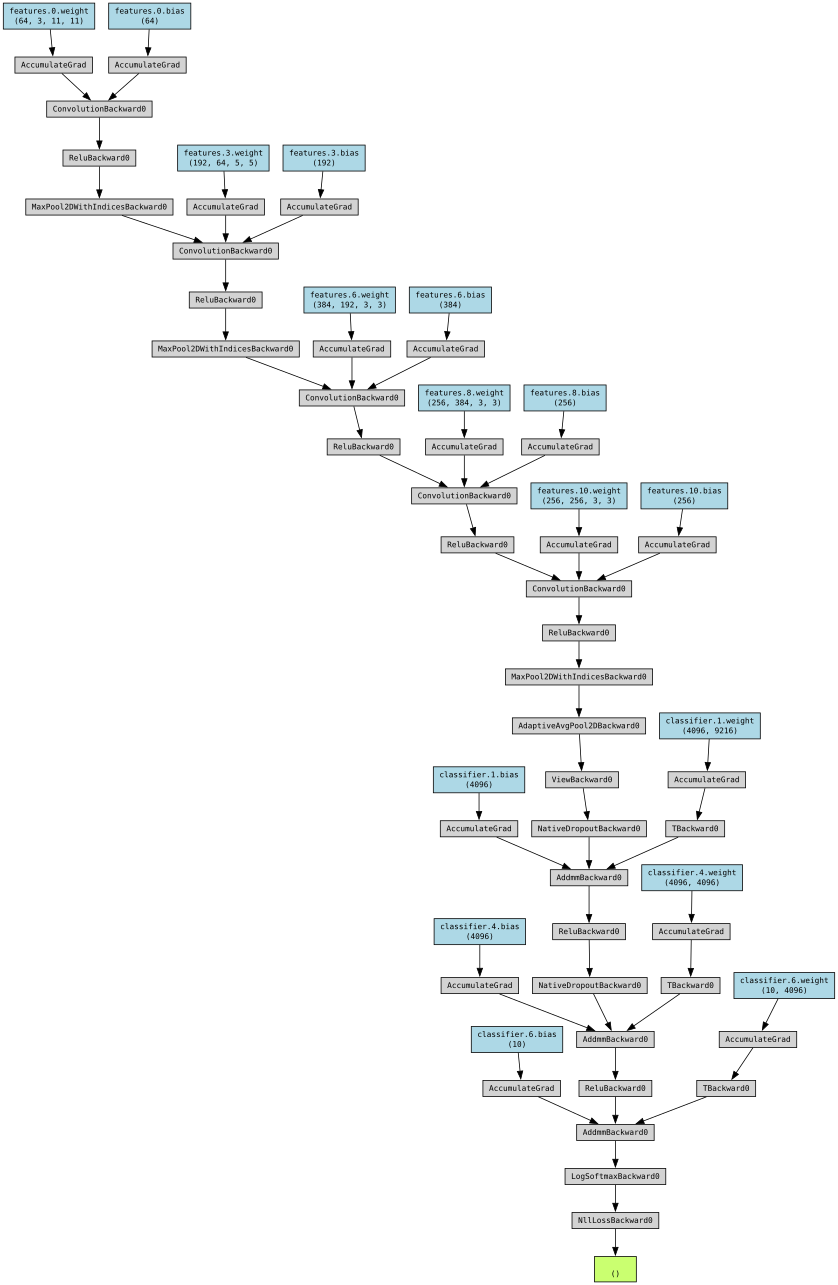

In [23]:
# 손실 계산 그래프 시각화
net = net.to(device)
criterion = nn.CrossEntropyLoss()
loss = eval_loss(test_loader, device, net, criterion)
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

## 학습과 결과 평가

### 초기 설정

In [39]:
# 난수 고정
torch_seed()

# 사전 학습 모델 불러오기
# pretraind = True로 학습을 마친 파라미터도 함께 불러오기
weights = models.AlexNet_Weights.IMAGENET1K_V1
net = models.alexnet(weights = weights)

# 최종 레이어 함수 입력 차원수 확인
in_features = net.classifier[6].in_features
net.classifier[6] = nn.Linear(in_features, n_output)

# 최종 레이어 함수 교체
net.fc = nn.Linear(in_features, n_output)

# GPU 사용
net = net.to(device)

# 학습률
lr = 0.001

# 손실 함수 정의
criterion = nn.CrossEntropyLoss()

# 최적화 함수 정의
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

# history 파일 초기화
history = np.zeros((0, 5))

### 학습

In [40]:
# 학습
num_epochs = 5
history = fit(net, optimizer, criterion, num_epochs, 
        train_loader, test_loader, device, history)

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [1/5], loss: 0.88723 acc: 0.68882 val_loss: 0.52400, val_acc: 0.81490


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [2/5], loss: 0.64617 acc: 0.77202 val_loss: 0.46861, val_acc: 0.83910


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [3/5], loss: 0.56864 acc: 0.80250 val_loss: 0.41946, val_acc: 0.85550


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [4/5], loss: 0.51698 acc: 0.81954 val_loss: 0.38899, val_acc: 0.86610


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [5/5], loss: 0.47502 acc: 0.83350 val_loss: 0.39600, val_acc: 0.86080


### 학습 결과 평가

초기상태 : 손실 : 0.52400  정확도 : 0.81490
최종상태 : 손실 : 0.39600 정확도 : 0.86080


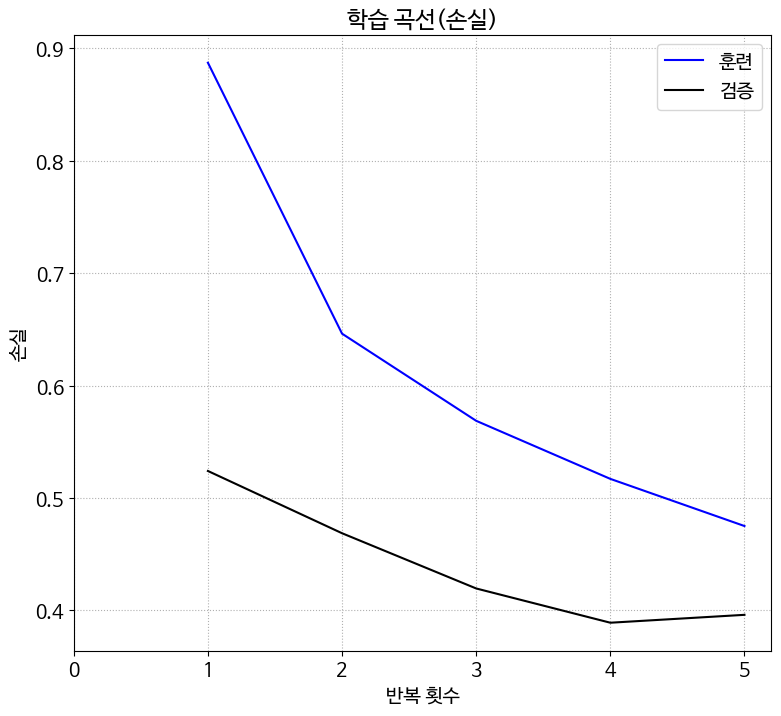

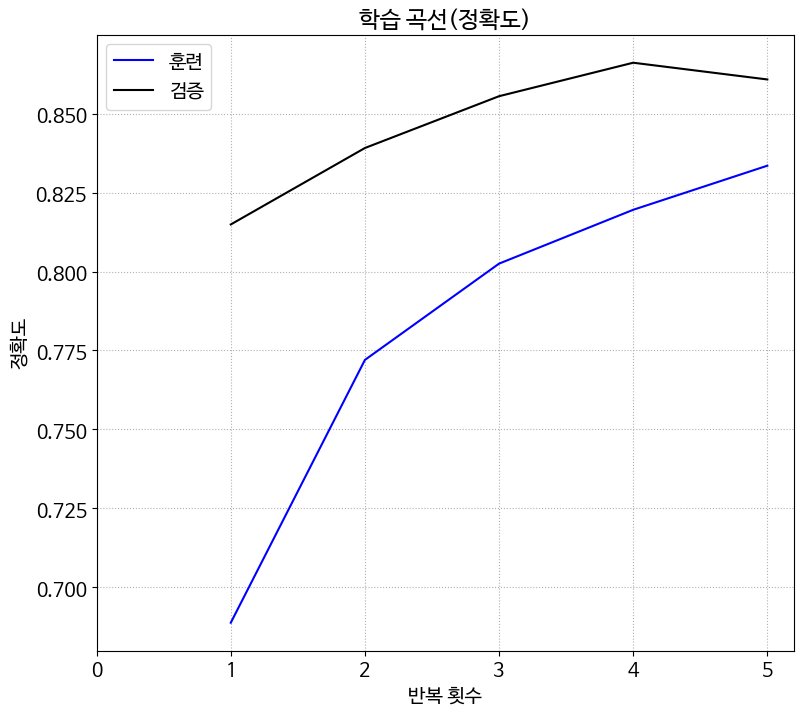

In [41]:
# 결과 요약
evaluate_history(history)

len(images) =  50


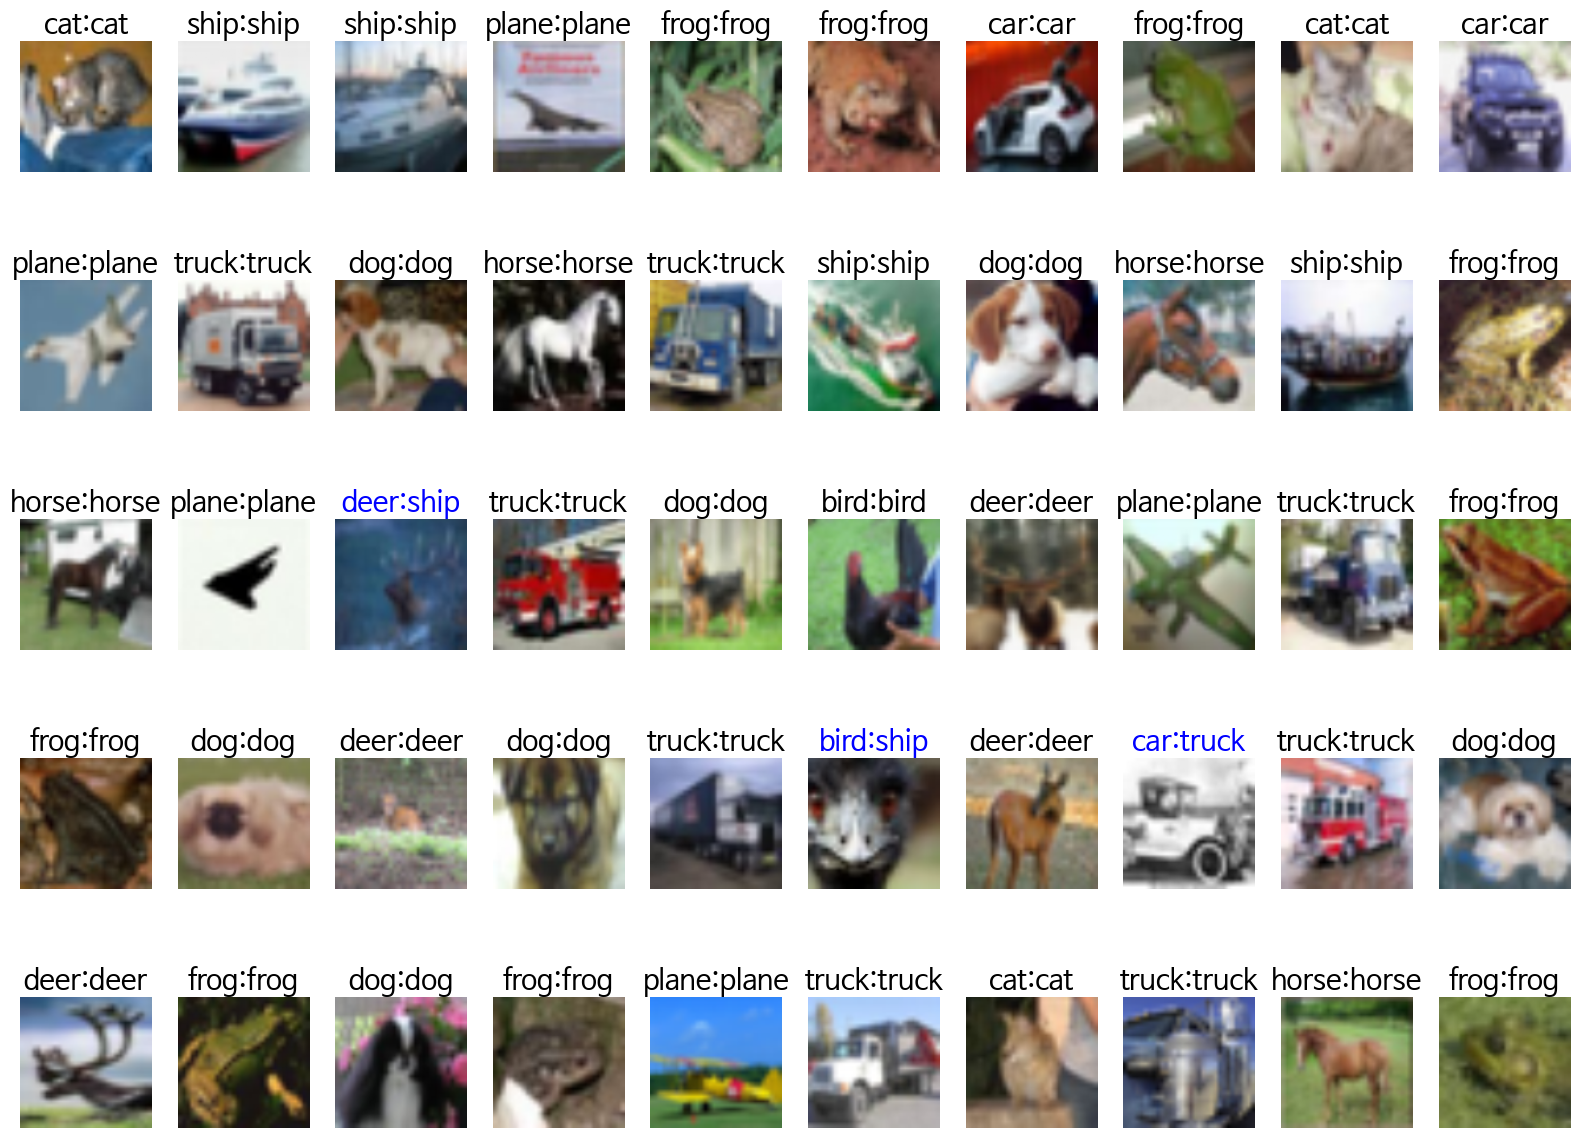

In [42]:
# 이미지와 정답, 예측 결과를 함께 표시
show_images_labels(test_loader, classes, net, device)

## GoogLeNet 불러 오기

### 모델 불러오기

In [65]:
#  라이브러리 임포트
from torchvision import models

# dir(models)
weights = models.GoogLeNet_Weights.IMAGENET1K_V1
net = models.googlenet(weights=weights)

In [66]:
# 모델 개요 표시 1
print(net)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [67]:
# 모델 개요 표시 2
# net = net.to(device)
summary(net, (100, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
GoogLeNet                                [100, 1000]               --
├─BasicConv2d: 1-1                       [100, 64, 112, 112]       --
│    └─Conv2d: 2-1                       [100, 64, 112, 112]       9,408
│    └─BatchNorm2d: 2-2                  [100, 64, 112, 112]       128
├─MaxPool2d: 1-2                         [100, 64, 56, 56]         --
├─BasicConv2d: 1-3                       [100, 64, 56, 56]         --
│    └─Conv2d: 2-3                       [100, 64, 56, 56]         4,096
│    └─BatchNorm2d: 2-4                  [100, 64, 56, 56]         128
├─BasicConv2d: 1-4                       [100, 192, 56, 56]        --
│    └─Conv2d: 2-5                       [100, 192, 56, 56]        110,592
│    └─BatchNorm2d: 2-6                  [100, 192, 56, 56]        384
├─MaxPool2d: 1-5                         [100, 192, 28, 28]        --
├─Inception: 1-6                         [100, 256, 28, 28]        --
│

## 파인 튜닝 없이 사용하기
### 영상 읽기

In [68]:
### Step 2: Read image
## rgb format, <class 'torch.Tensor'>
from torchvision.io import read_image

net.eval()

filename = "./beagle.jpg"
img = read_image(filename) # torch.Size([3, 366, 640]) 
img = img.to(device)

##
print("img type = ", type(img))
print("img shape = ", img.shape) # torch.Size([3, 366, 640]))

img type =  <class 'torch.Tensor'>
img shape =  torch.Size([3, 366, 640])


### 영상 변환

In [69]:
# preprocess
# Scaling pixel values down to the [0, 1] range from their original [0, 255] range before applying normalization.
# ImageClassification(
#     crop_size=[224]
#     resize_size=[256]
#     mean=[0.485, 0.456, 0.406]
#     std=[0.229, 0.224, 0.225]
#     interpolation=InterpolationMode.BILINEAR
# )

preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


### 변환 영상 확인하기

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.3611333].


torch.Size([1, 3, 224, 224])


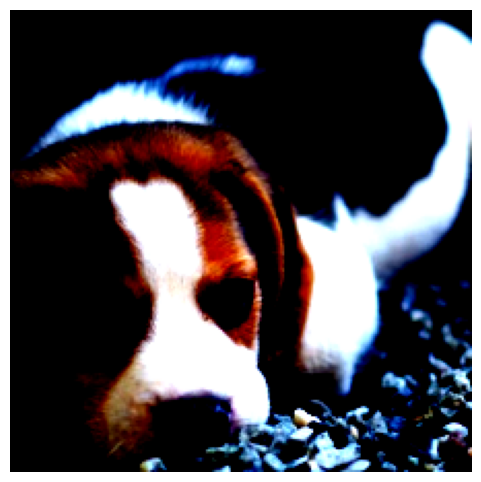

In [70]:
batch = preprocess(img).unsqueeze(0).to(device)
print(batch.shape)

##
processed_img = batch.data[0]
plt_img = processed_img.permute(1, 2, 0)

# plt_img.shape
plt.imshow(plt_img.cpu().numpy())
plt.grid(visible = None)
plt.axis("off")
plt.show()

In [71]:
# Step 5: Use the model and print the predicted category
net = net.to(device)
prediction = net(batch).softmax(1) # (1, 1000)
class_id = prediction.argmax().item() 
print("class id = ", class_id)

class id =  162


### 결과 확인 하기

In [72]:
display("category = \n", weights.meta["categories"])
print("category number = ", len(weights.meta["categories"]))

'category = \n'

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich',
 'brambling',
 'goldfinch',
 'house finch',
 'junco',
 'indigo bunting',
 'robin',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'water ouzel',
 'kite',
 'bald eagle',
 'vulture',
 'great grey owl',
 'European fire salamander',
 'common newt',
 'eft',
 'spotted salamander',
 'axolotl',
 'bullfrog',
 'tree frog',
 'tailed frog',
 'loggerhead',
 'leatherback turtle',
 'mud turtle',
 'terrapin',
 'box turtle',
 'banded gecko',
 'common iguana',
 'American chameleon',
 'whiptail',
 'agama',
 'frilled lizard',
 'alligator lizard',
 'Gila monster',
 'green lizard',
 'African chameleon',
 'Komodo dragon',
 'African crocodile',
 'American alligator',
 'triceratops',
 'thunder snake',
 'ringneck snake',
 'hognose snake',
 'green snake',
 'king snake',
 'garter snake',
 'water snake',
 'vine snake',
 'night snake',
 'boa constrictor',
 'rock python',
 'Indian cobr

category number =  1000


In [73]:
category_name = weights.meta["categories"][class_id]
category_name

'beagle'

## 최종 레이어 함수 교체하기 (전이 학습)


In [74]:
# 모델 개요 표시 1
print(net)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [75]:
# 모델 개요 표시 
summary(net,(100, 3, 112, 112))

Layer (type:depth-idx)                   Output Shape              Param #
GoogLeNet                                [100, 1000]               --
├─BasicConv2d: 1-1                       [100, 64, 56, 56]         --
│    └─Conv2d: 2-1                       [100, 64, 56, 56]         9,408
│    └─BatchNorm2d: 2-2                  [100, 64, 56, 56]         128
├─MaxPool2d: 1-2                         [100, 64, 28, 28]         --
├─BasicConv2d: 1-3                       [100, 64, 28, 28]         --
│    └─Conv2d: 2-3                       [100, 64, 28, 28]         4,096
│    └─BatchNorm2d: 2-4                  [100, 64, 28, 28]         128
├─BasicConv2d: 1-4                       [100, 192, 28, 28]        --
│    └─Conv2d: 2-5                       [100, 192, 28, 28]        110,592
│    └─BatchNorm2d: 2-6                  [100, 192, 28, 28]        384
├─MaxPool2d: 1-5                         [100, 192, 14, 14]        --
├─Inception: 1-6                         [100, 256, 14, 14]        --
│

In [76]:
print(net.fc)
print(net.fc.in_features)
print(net.fc.out_features)

Linear(in_features=1024, out_features=1000, bias=True)
1024
1000


In [77]:
torch_seed()
in_features = net.fc.in_features
net.fc = nn.Linear(in_features, n_output)

In [78]:
# 모델 개요 표시 1
print(net)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

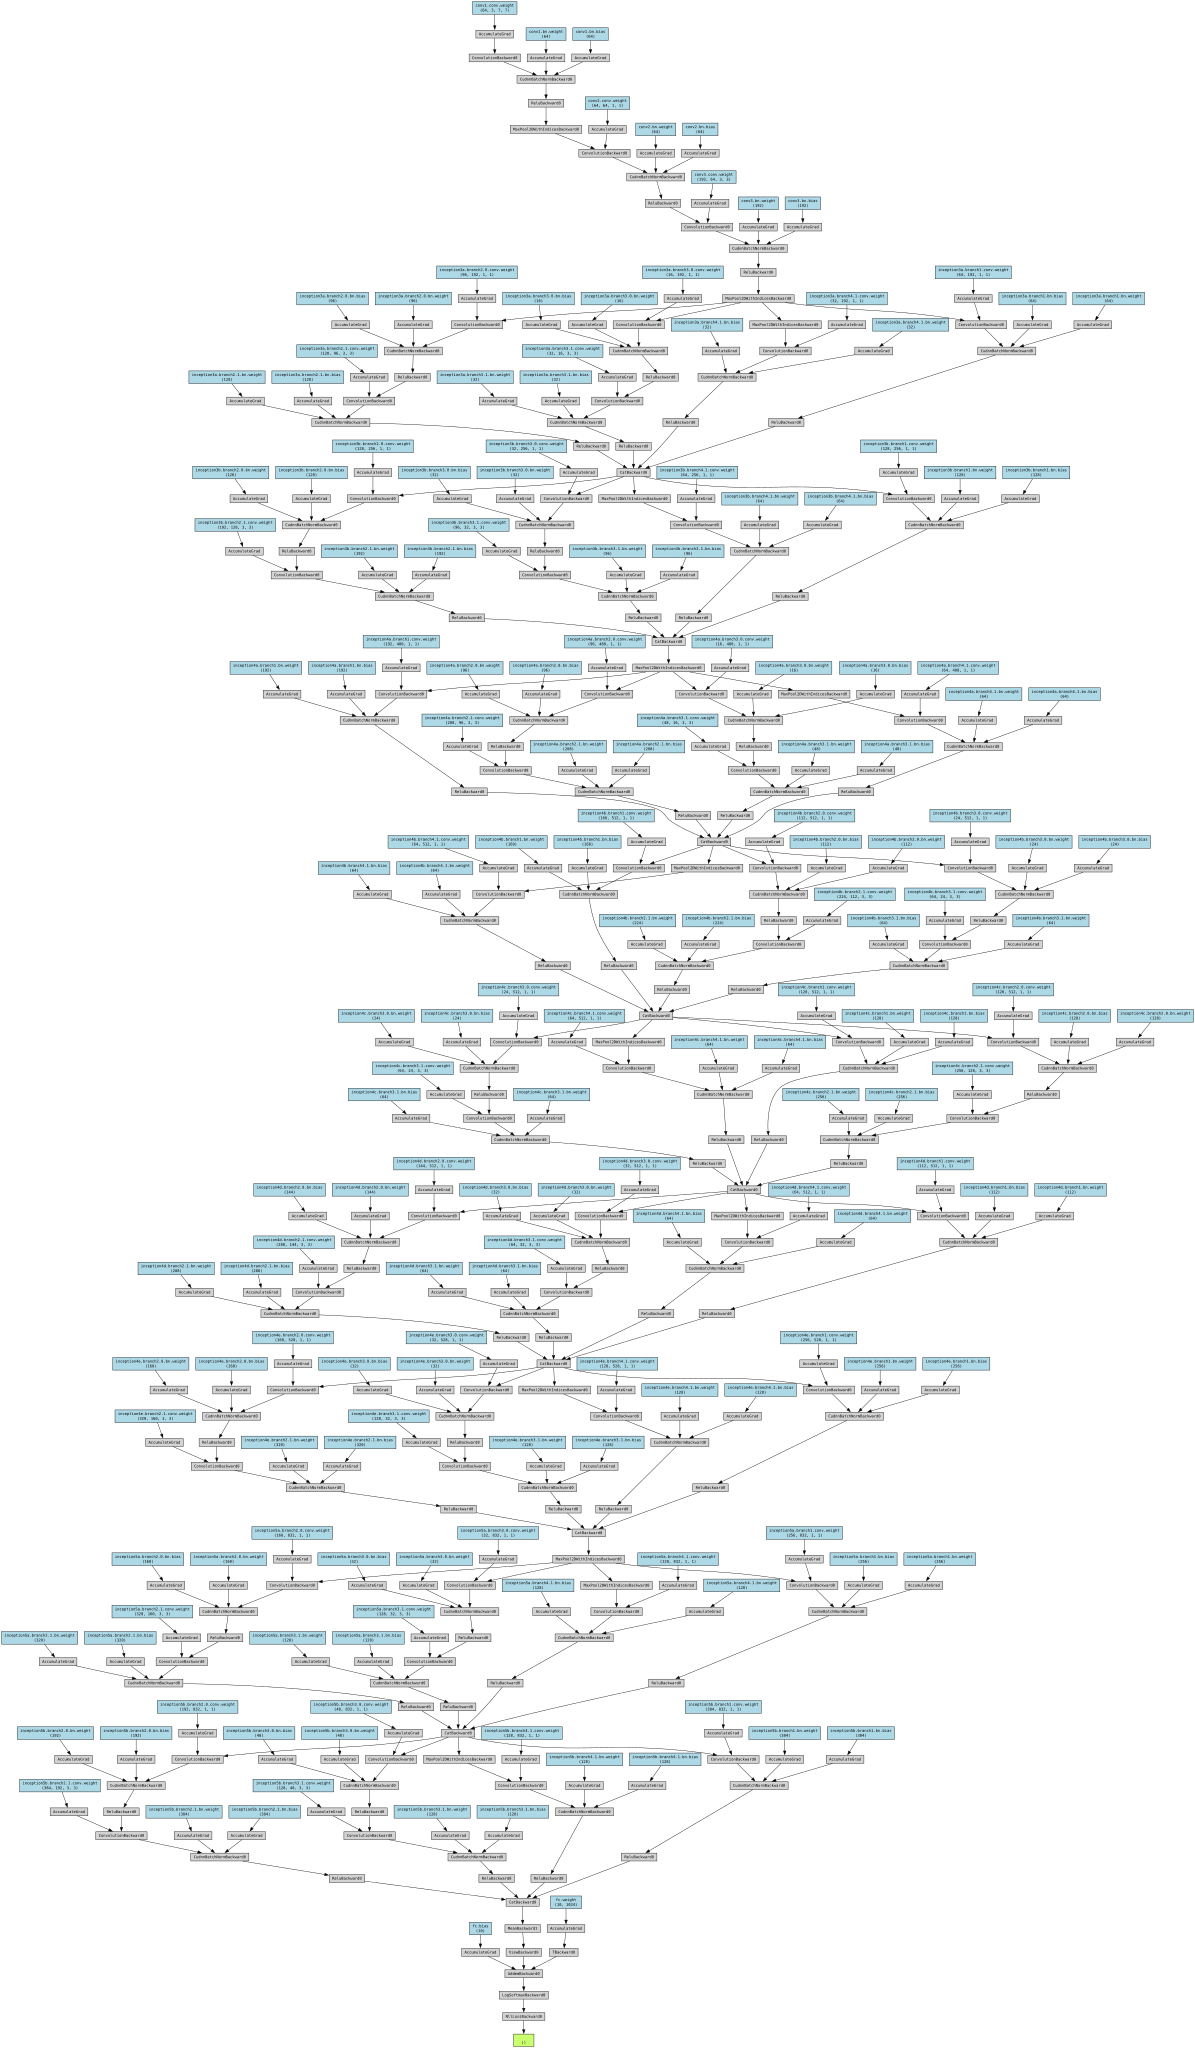

In [79]:
# 손실 계산 그래프 시각화
net = net.to(device)
criterion = nn.CrossEntropyLoss()
loss = eval_loss(test_loader, device, net, criterion)
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

## 학습과 결과 평가

### 초기 설정

In [80]:
# 난수 고정
torch_seed()

# 사전 학습 모델 불러오기
# pretraind = True로 학습을 마친 파라미터도 함께 불러오기
weights = models.GoogLeNet_Weights.IMAGENET1K_V1
net = models.googlenet(weights=weights)

# 최종 레이어 함수 입력 차원수 확인
in_features = net.fc.in_features
net.fc = nn.Linear(in_features, n_output)

# 최종 레이어 함수 교체
net.fc = nn.Linear(in_features, n_output)

# GPU 사용
net = net.to(device)

# 학습률
lr = 0.001

# 손실 함수 정의
criterion = nn.CrossEntropyLoss()

# 최적화 함수 정의
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

# history 파일 초기화
history = np.zeros((0, 5))

### 학습

In [81]:
# 학습
num_epochs = 5
history = fit(net, optimizer, criterion, num_epochs, 
        train_loader, test_loader, device, history)

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [1/5], loss: 0.82228 acc: 0.72988 val_loss: 0.31814, val_acc: 0.89200


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [2/5], loss: 0.41222 acc: 0.86000 val_loss: 0.23791, val_acc: 0.91640


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [3/5], loss: 0.33283 acc: 0.88782 val_loss: 0.20396, val_acc: 0.92910


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [4/5], loss: 0.28708 acc: 0.90082 val_loss: 0.19425, val_acc: 0.93320


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [5/5], loss: 0.24786 acc: 0.91622 val_loss: 0.17743, val_acc: 0.94010


### 학습 결과 평가

초기상태 : 손실 : 0.31814  정확도 : 0.89200
최종상태 : 손실 : 0.17743 정확도 : 0.94010


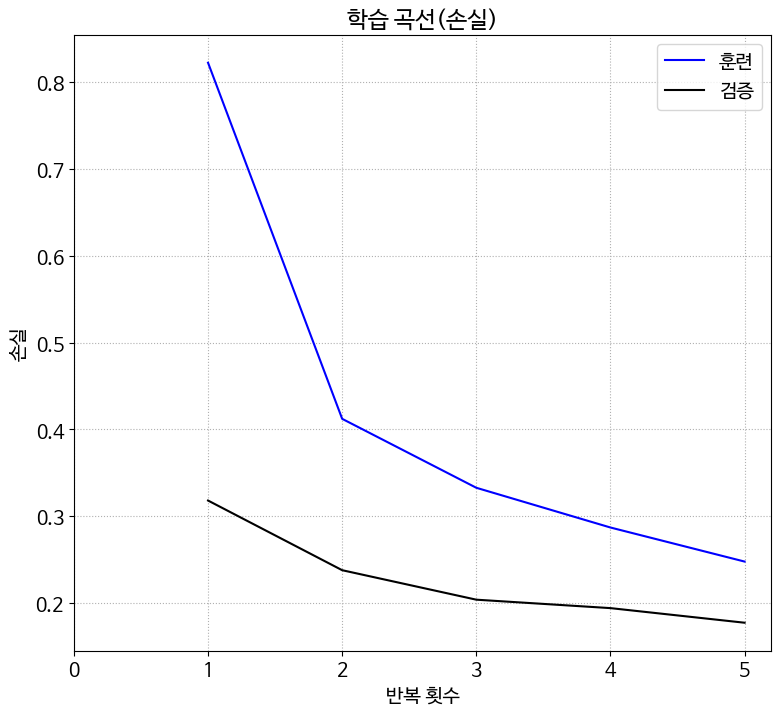

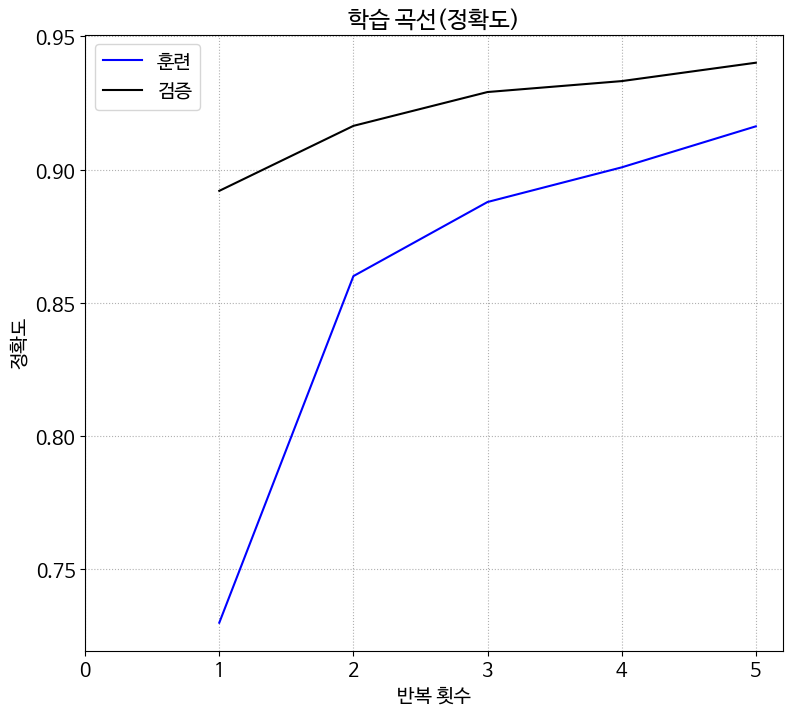

In [82]:
# 결과 요약
evaluate_history(history)

len(images) =  50


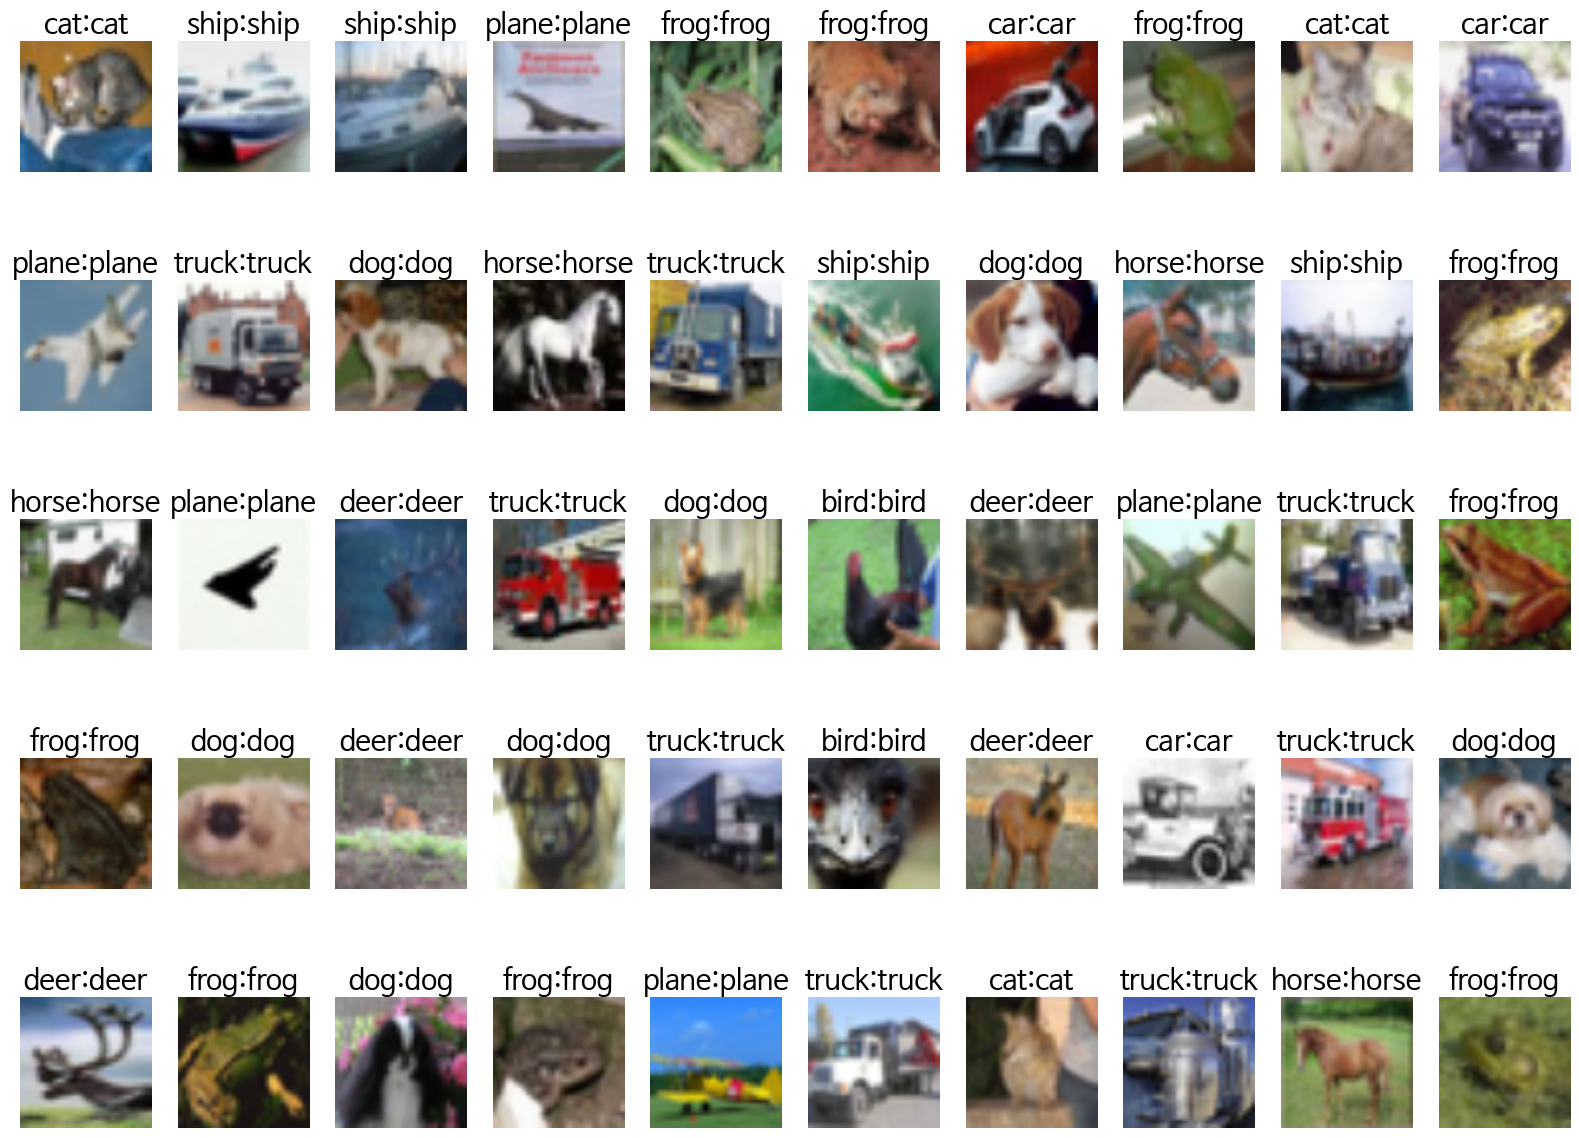

In [83]:
# 이미지와 정답, 예측 결과를 함께 표시
show_images_labels(test_loader, classes, net, device)